In [2]:
import numpy as np
import pandas as pd
import matlab.engine
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

eng = matlab.engine.start_matlab()

In [3]:
def shell_radii(fractions, R):
    """
    Computes cumulative radii of a multilayer system.
    Model: r_i = R * (x_i)^(1/3)
    where x_i is the cumulative sum of fractions.
    """
    x = np.cumsum(fractions) #cumulative sum
    r = R * np.cbrt(x) #cube root
    return r

def mono_exp(x, TB):
    return 1 - np.exp(-x / TB)  # beta = 1

def fit_mono(df_group, y_label):
    t = df_group["t"].values
    y = df_group[y_label].values
    popt, _ = curve_fit(mono_exp, t, y, bounds=([0], [np.inf]))
    TB = popt[0]
    yfit = mono_exp(t, *popt)
    return pd.Series({"TB": TB, "yfit": yfit, "R2": r2(y, yfit), "residuals" : y - yfit}) 

def stretched_exp(x, TB, beta):
    return 1 - np.exp(-(x / TB) ** beta)

def fit_stretched(df_group, y_label):
    t = df_group["t"].values
    y = df_group[y_label].values
    popt, _ = curve_fit(stretched_exp, t, y,bounds=([0, 0], [np.inf, np.inf]))
    TB, beta = popt
    yfit = stretched_exp(t, *popt)
    return pd.Series({"TB": TB, "beta" : beta, "yfit": yfit, "R2": r2(y, yfit), "residuals" : y - yfit}) 

def r2(y, yfit):
    ss_res = np.sum((y - yfit) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot 

R = 0.05 #radius of LNP in um
compounds =  ["mRNA", "Lipid A", "Lipid B", "Cholesterol", "Lipid C"]
distrib =  np.array([0.04, 0.24, 0.24, 0.24, 0.24]) # fictious

## defining models

In [4]:
rows = []
rows_name = []

#control
rows.append((1, 1, 1.0, 0.0, 0.0, 0.0, 0.0))
rows.append((1, 2, 0.0, 1.0, 0.0, 0.0, 0.0))
rows.append((1, 3, 0.0, 0.0, 1.0, 0.0, 0.0))
rows.append((1, 4, 0.0, 0.0, 0.0, 1.0, 0.0))
rows.append((1, 5, 0.0, 0.0, 0.0, 0.0, 1.0))

# Cholesterol homogeneously distributed in the lipid layers
rows.append((2, 1, 1.0, 0.0, 0.0, 0.0, 0.0))
rows.append((2, 2, 0.0, 1.0, 0.0, 1.0, 0.0))
rows.append((2, 3, 0.0, 0.0, 1.0, 1.0, 0.0))
rows.append((2, 4, 0.0, 0.0, 0.0, 1.0, 1.0))
rows_name.append((2, "I"))

# Cholesterol heterogeneously distributed in the lipid layers: 
rows.append((3, 1, 1.0, 0.0, 0.0, 0.0, 0.0))
rows.append((3, 2, 0.0, 1.0, 0.0, 0.5, 0.0)) # 1:0.1
rows.append((3, 3, 0.0, 0.0, 1.0, 1.0, 0.0)) # 1:1
rows.append((3, 4, 0.0, 0.0, 0.0, 10.0, 1.0)) # 1:10
rows_name.append((3, "II"))

models = pd.DataFrame(rows, columns=["model", "shell", "mRNA", "Lipid A", "Lipid B", "Cholesterol", "Lipid C"]).set_index(["model", "shell"])
id_models = models.index.get_level_values("model").unique()
index = models.index.names

In [5]:
models_shells = models.div(models.sum(axis=1), axis=0) # relative contribution per shell
#print("nb of shell :", models_shells.groupby("model").sum().sum(axis=1))
models_compound = models_shells.divide(models_shells.groupby("model").sum()) # relative contribution per compound
#print("number of compound :", models_compound.groupby("model").sum().sum(axis=1))
models_distrib = models_compound.mul(distrib) # relative volume contributions
# print("total volume :", models_distrib.groupby("model").sum().sum(axis=1))

## start processing data : getting raddi

In [6]:
models_data = pd.DataFrame(0, index=models.index, columns=[])

# store the contribution of each shell
models_data["%"] = models_distrib.sum(axis = 1)
#print("total shell :", models_data["%"].groupby("model").sum())

radii = models_data["%"].groupby("model").transform(lambda s: shell_radii(s, R))

models_data["r_max"] = radii #um
models_data["r_min"] = radii.groupby("model").shift(fill_value=0) #um
models_data["thickness"] = np.round((models_data["r_max"] - models_data["r_min"])*1e3, 3) #nm

radiis = radii.groupby("model").apply(lambda s: np.pad(s, (1,0)))
radiis = radiis.to_frame("radii")

models_data

%     r_max     r_min  thickness
model shell                                         
1     1      0.040000  0.017100  0.000000     17.100
      2      0.240000  0.032711  0.017100     15.611
      3      0.240000  0.040207  0.032711      7.497
      4      0.240000  0.045629  0.040207      5.422
      5      0.240000  0.050000  0.045629      4.371
2     1      0.040000  0.017100  0.000000     17.100
      2      0.320000  0.035569  0.017100     18.469
      3      0.320000  0.043968  0.035569      8.399
      4      0.320000  0.050000  0.043968      6.032
3     1      0.040000  0.017100  0.000000     17.100
      2      0.285913  0.034409  0.017100     17.309
      3      0.308870  0.042971  0.034409      8.562
      4      0.365217  0.050000  0.042971      7.029

## storage for plots : 
* nb of point for a compound in a shell : N = x * A * k
* x : ratio of this compound in the shell
* A : area of the shell
* k : multiplication factor (r_max and r_min are in um not nm, area is reaaaally small)


In [7]:
area = np.pi * (models_data["r_max"]**2 - models_data["r_min"]**2)  
nb_points = models_shells.loc[models_shells.index, compounds]
k = 1.5e6
nb_points = np.round(nb_points.mul(area, axis=0) * k ).astype(int)    
total_points = nb_points.groupby("model").sum().sum(axis =1)
print(total_points)

rows = []
for model, shell in models.index:
    r_min = models_data.loc[(model, shell), "r_min"]
    r_max = models_data.loc[(model, shell), "r_max"]
    for c in compounds:
        n_points = nb_points.loc[(model, shell), c]
        
        #uniform distribution on the area of the shell
        phi = np.random.uniform(0, 2*np.pi, n_points)
        r = np.sqrt(np.random.uniform(r_min**2, r_max**2, n_points))
        
        # convert from polar to cartesian 
        x = r * np.cos(phi)
        y = r * np.sin(phi)
        for k in range(n_points):
            rows.append((model, shell, c, x[k], y[k]))

#store for drawing later
models_points = pd.DataFrame(rows, columns=["model","shell","compound", "x", "y"])
models_points = models_points.set_index(["model", "shell", "compound"])

model
1    11781
2    11780
3    11780
dtype: int64


## spin diffusion simulation

In [8]:
m = 2                 # m=0 for 1D, m=1 for 2D, m=2 for 3D

rstep = 1000          # number of points in space domain
tmax = 100            # maximum time in s
tstep = 200           # number of points in time domain

epsilon0 = 154        # source enhancement
T1source = 2.3        # source build up time in s
T1target = 4.5        # intrinsic relaxation time of the target in s

slope = 60000         # slope of the tanh function
theta = 0.9           # percentage of quenched signal in the source
dep = 0.5             # percentage of depolarization in the source
Cp = 2.54e-2          # Molar heat capacity of 1H spins at 9.4 T Prisco_2021

length_target = R     # length of the target in um
length_source = 0.09  # length of the source in um

concX = 117           # 1H concentration in the target in molar
concjuice = 12        # 1H concentration in the source in molar
Din = 1.5e-4          # LNP diffusion coefficient based on Viger-Gravel_2018
MAS = 12              # MAS rate in kHz
D0 = 4.25e-3          # fictive diffusion coefficient of PS in a static sample: Pinon_thesis
#The source diffusion coeff is scaled with the proton concentration and MAS
Dout = D0*(concjuice/70)**(1/3)/(1+0.6*MAS)

rows = []

for id_model in radiis.index:
    r = radiis.loc[id_model]

    signals = eng.spin_diffusion(
    float(m), float(length_target), float(rstep), float(tmax), float(tstep), 
    float(T1source), float(T1target), float(epsilon0), float(Din), float(Dout),
    float(length_source), float(slope), float(theta), float(dep), float(concjuice), 
    float(concX), float(Cp), matlab.double(r.tolist()))
    
    for i, (s_off, s_on, t) in enumerate( zip(signals["S_off"], signals["S_on"], signals["t"])):
        #m.double (matlab) to np.array
        s_off = np.array(s_off)[0] 
        s_on = np.array(s_on)[0]
        t = np.array(t)[0]    
        for ti, off, on in zip(t, s_off, s_on):
            rows.append({"model" : id_model, "shell": i+1, "t": ti, "S_off": off, "S_on": on})
    print(f"model {id_model} processed")

models_signals = pd.DataFrame(rows)
models_signals = models_signals.set_index(["model", "shell"])

model 1 processed
model 2 processed
model 3 processed


## observables computation

In [9]:
models_signals["epsilon"]= models_signals["S_on"] / models_signals["S_off"] 
models_signals.loc[models_signals["epsilon"].isna(), "epsilon"] = 0

#recycle time d1 used in experiment -> taking enhancement at that time 
d1 = 5.5 # in s 
models_signals["dist"] = np.abs(models_signals["t"] - d1) 
dist_min = models_signals.sort_values("dist").groupby(["model", "shell"]).head(1) #minimal distance from d1
models_data["epsilon_d1"] = dist_min.sort_index(level=["model", "shell"])["epsilon"]
# models_data

In [10]:
# normalized S_on for TB fit
S_on_max = models_signals.sort_values("S_on").groupby(["model", "shell"]).tail(1)
models_signals["normS_on"] = models_signals["S_on"]  / S_on_max.sort_index(level=["model", "shell"])["S_on"]

# fitting for having TB 
# mono exponential
fit_m = models_signals.groupby(["model", "shell"]).apply(fit_mono, "normS_on")
models_data["TB_m"] = fit_m["TB"]
models_data["R2_m"] = fit_m["R2"]
models_signals["fit_m"] = fit_m["yfit"].explode()
models_signals["residuals_m"] = fit_m["residuals"].explode()

# stretched exponential
fit_s = models_signals.groupby(["model", "shell"]).apply(fit_stretched, "normS_on")
models_data["TB_s"] = fit_s["TB"]
models_data["R2_s"] = fit_s["R2"]
models_data["beta"] = fit_s["beta"]
models_signals["fit_s"] = fit_s["yfit"].explode()
models_signals["residuals_s"] = fit_s["residuals"].explode()

# models_data

## results : from shell to component

In [11]:
result = ["epsilon_d1", "TB_m", "TB_s"]

models_result = pd.DataFrame(0.0, 
                            index = pd.MultiIndex.from_product([id_models, compounds], 
                            names=["model", "compound"]), 
                            columns=result)

# using models_compound to have the contribution of each compound 
epsilon_values = models_compound.mul(models_data["epsilon_d1"], axis=0).groupby("model").sum()
epsilon_values = epsilon_values.stack()
models_result["epsilon_d1"] = epsilon_values

TB_m_values = models_compound.mul(models_data["TB_m"], axis=0).groupby("model").sum()
TB_m_values = TB_m_values.stack()
models_result["TB_m"] = TB_m_values

TB_s_values = models_compound.mul(models_data["TB_s"], axis=0).groupby("model").sum()
TB_s_values = TB_s_values.stack()
models_result["TB_s"] = TB_s_values
models_result

epsilon_d1      TB_m      TB_s
model compound                                   
1     mRNA          13.747663  6.323905  6.687925
      Lipid A       17.392246  5.773215  6.086761
      Lipid B       22.122331  5.194128  5.437879
      Cholesterol   26.375598  4.763410  4.944421
      Lipid C       30.515792  4.404983  4.525854
2     mRNA          13.747663  6.323905  6.687925
      Lipid A       18.191657  5.664925  5.966730
      Lipid B       24.260481  4.967974  5.179895
      Cholesterol   24.089194  5.031509  5.246332
      Lipid C       29.815445  4.461628  4.592371
3     mRNA          13.747663  6.323905  6.687925
      Lipid A       17.860583  5.709287  6.015979
      Lipid B       23.573058  5.038433  5.260541
      Cholesterol   25.535909  4.882375  5.075826
      Lipid C       29.429763  4.493342  4.629509

## visualization

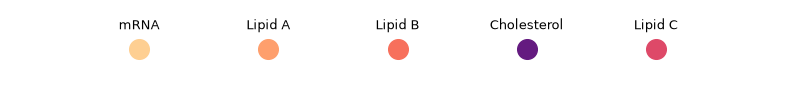

In [12]:
cmap = plt.get_cmap("Spectral")(np.linspace(0.1, 0.9, 5))
cmap = plt.get_cmap("magma")(np.linspace(0.2, 0.9, 8))

compound_colors = {
        "mRNA": cmap[7],
        "Lipid A": cmap[6],
        "Lipid B": cmap[5],
        "Cholesterol":cmap[1], 
        "Lipid C":cmap[4]
    } 
fig, ax = plt.subplots(figsize=(10, 1))
for i, (c, color) in enumerate(compound_colors.items()):
    ax.scatter(i, 0, color=color, s=200)
    ax.text(i, 0.5, str(c), ha='center', fontsize=9)
ax.set_xlim(-1, len(compound_colors))
ax.set_ylim(-1, 1)
ax.axis("off")

plt.show()

In [13]:
plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 25,
    "axes.titlesize": 20,
    "xtick.labelsize": 15,
    "legend.fontsize": 25,
    "figure.titlesize": 20,
})

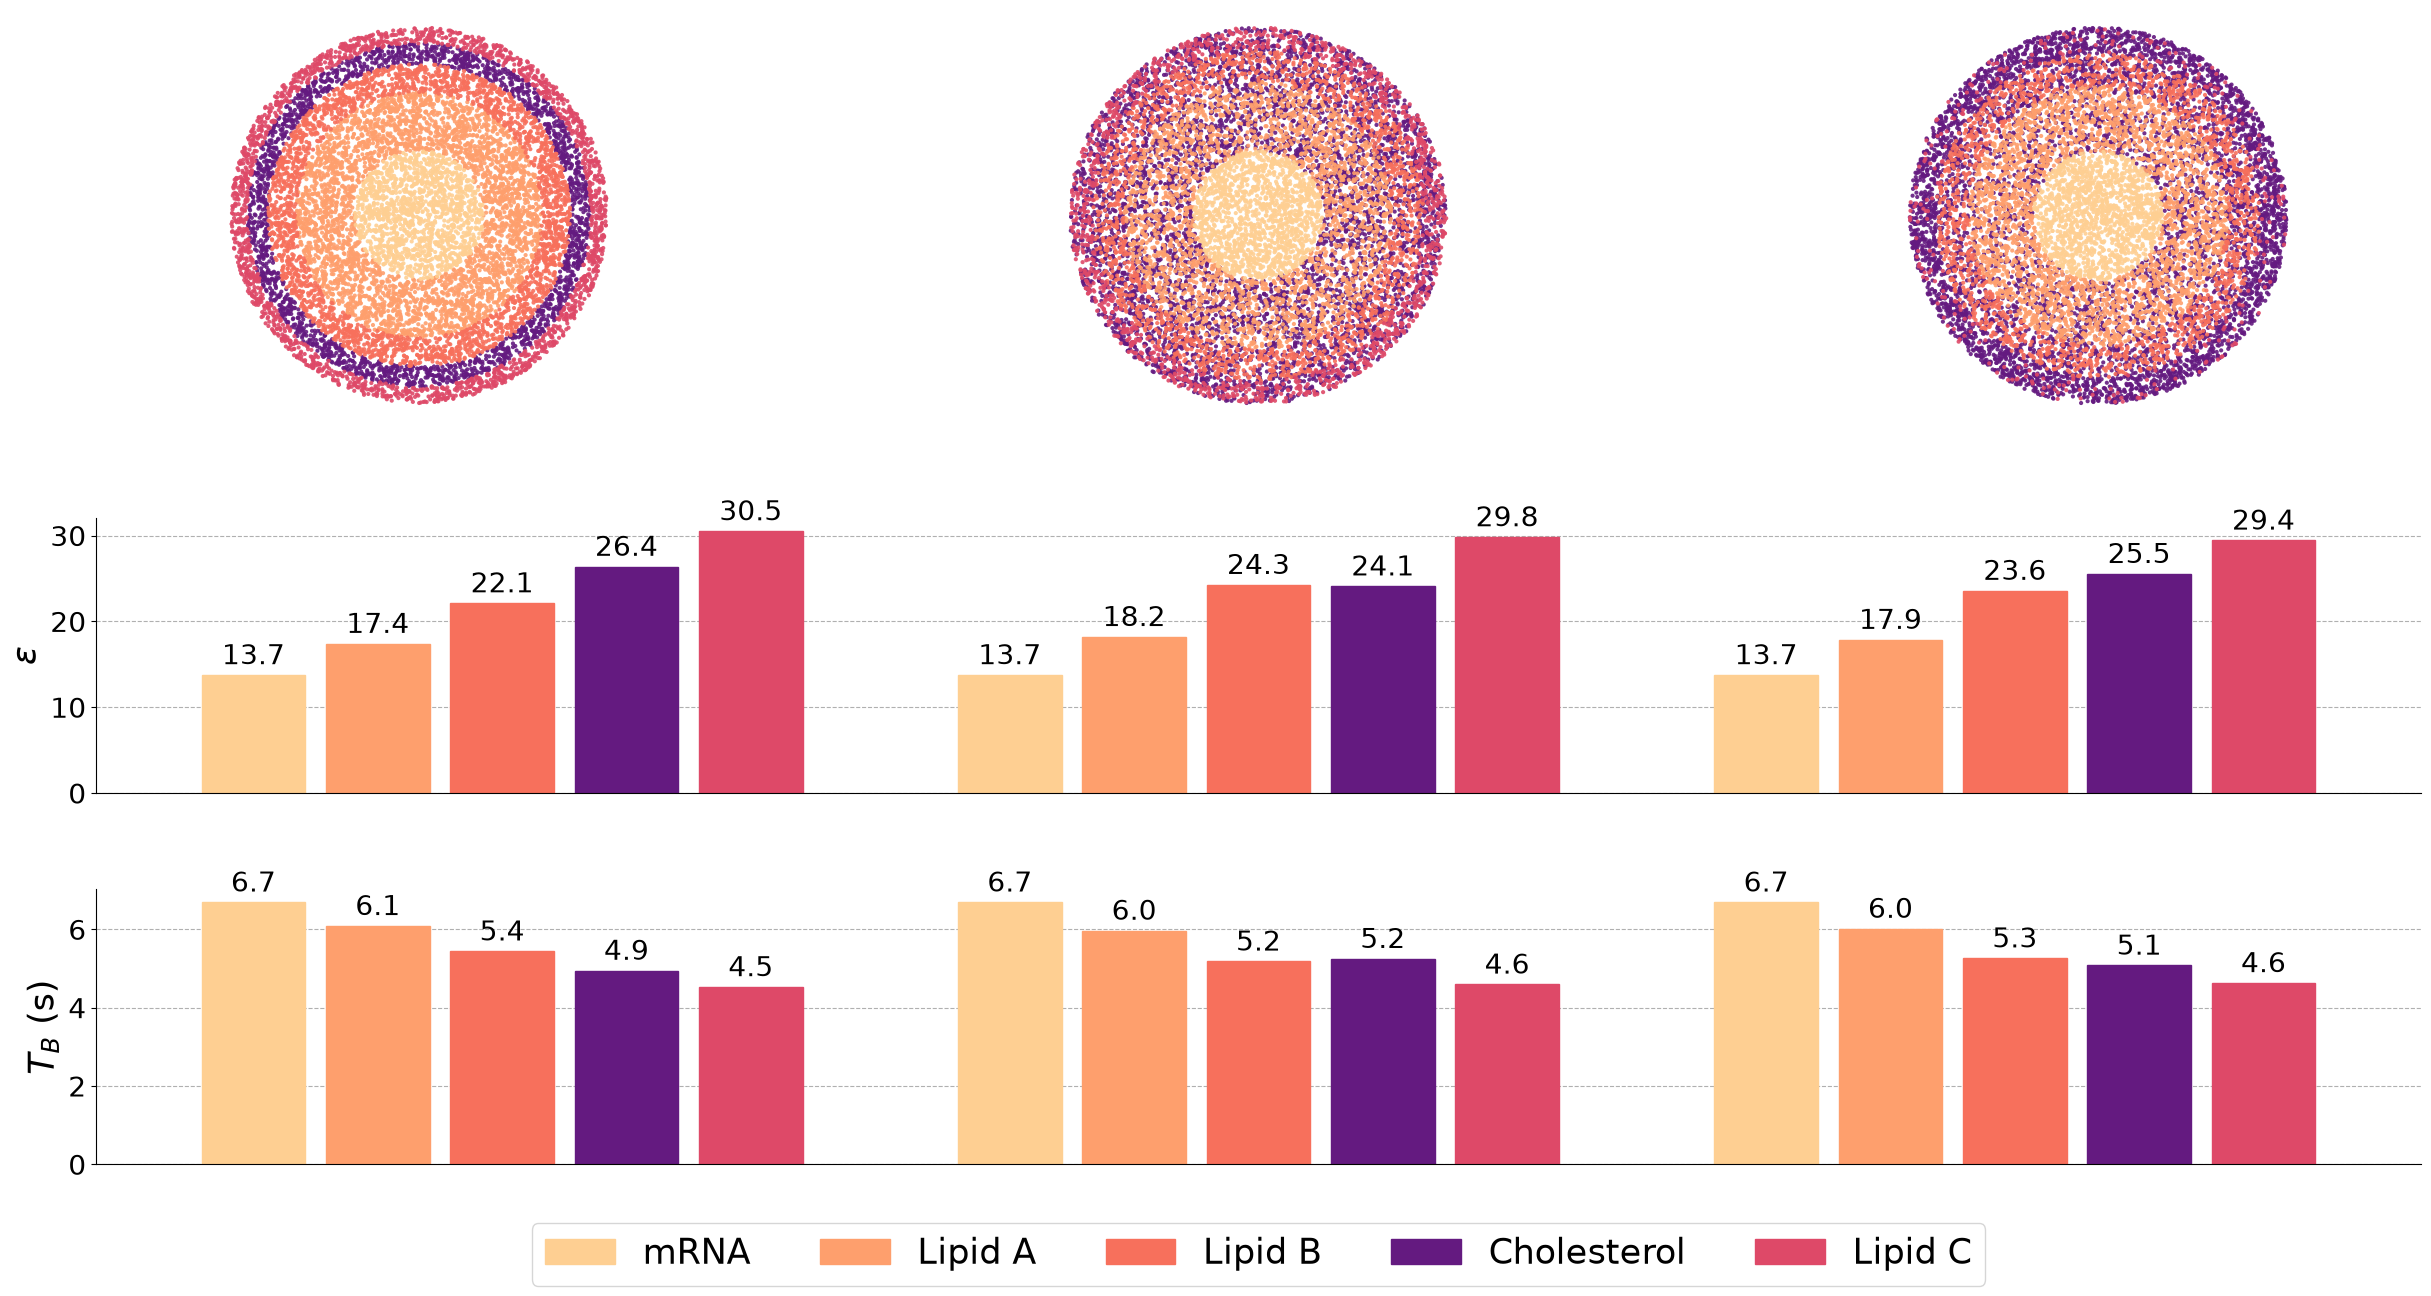

In [14]:
fig = plt.figure(figsize=(30, 15))
N = len(id_models)
gs = fig.add_gridspec(3, N, height_ratios=[1.5, 1, 1])

axes = {}
for n in range(N):
    base = n
    axes[f"lnp_{n}"] = fig.add_subplot(gs[0, base])
axes[f"epsilon"] = fig.add_subplot(gs[1, :])
axes[f"TB"] = fig.add_subplot(gs[2, :])

for n, (name, model_points) in enumerate(models_points.groupby("model")):
    ax = axes[f"lnp_{n}"]
    for c, compound_points in model_points.groupby("compound"):
        ax.scatter(compound_points["x"], compound_points["y"],s=9, alpha=0.9, edgecolors='none', color = compound_colors[c])
        ax.set_aspect("equal")
        ax.axis('off')

epsilon = models_result["epsilon_d1"].unstack().reindex(columns=compounds)

ax1 = axes["epsilon"]
ax1.set_ylabel(r"$\varepsilon$")
ax1.grouped_bar(epsilon, bar_spacing=0.2)
ax1.set_xticks([])

for container, compound in zip(ax1.containers, epsilon.columns):
    for bar in container:
        bar.set_color(compound_colors[compound])    
    labels = [f"{v:.1f}" for v in epsilon[compound]]
    ax1.bar_label(container, labels=labels, padding=3)

TB = models_result["TB_s"].unstack().reindex(columns=compounds)

ax2 = axes["TB"]
ax2.set_ylabel(r"$T_B$ (s)")
ax2.grouped_bar(TB, bar_spacing=0.2)
ax2.set_xticks([])

for container, compound in zip(ax2.containers, TB.columns):
    for bar in container:
        bar.set_color(compound_colors[compound])
    labels = [f"{v:.1f}" for v in TB[compound]]
    ax2.bar_label(container, labels=labels, padding=3)

ax2.legend(ncol=len(compounds),loc="upper center", bbox_to_anchor=(0.5, -0.15))
        
for ax in (ax1, ax2):
    ax.grid(True, axis="y", linestyle="--")
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.subplots_adjust(hspace=0.3, wspace = 0.3)
plt.savefig("gradient.png", dpi=150, bbox_inches="tight")
plt.show()